# Chapter 5: The Relational Data Model and Relational Database Constraints


## Teaching Summary

What does one row mean? The first-meeting selection introduces relations, tuples,
attributes, domains, and the purpose of identifiers. Read Chapters 1-2 first.
You only need to compare values and read a table; programming syntax is not a prerequisite.

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, seventh edition,
selected opening concepts from Section 5.1. Formal keys and integrity constraints
from Sections 5.2-5.3 are the chapter's continuation, not first-meeting requirements.
The continuation is included after First-Meeting Summary and Practice in this same
notebook. Read it when the instructor resumes the chapter.

You should be able to identify a complete tuple and an attribute value, distinguish
the domain from observed values, compare repeated values with duplicate tuples,
and explain why a person's name may not identify one student.


## 1. Read One Student Table

In the relational model, a **relation** is a set of tuples. A **tuple** is one complete
row of values; an **attribute** names a position or role in its schema. We display
relations as tables, but an unrestricted SQL table can allow duplicate rows and is
not automatically a mathematical set.

The schema here is `student(student_id, email, student_name, dept_code)`. Each row
describes one student, not one enrollment. IM means Information Management, FIN means
Finance, and DES means Digital Design. These are synthetic records, not personal data.

| student_id | email | student_name | dept_code |
|---|---|---|---|
| S101 | an@example.test | An Chen | IM |
| S102 | bea@example.test | Bea Lin | FIN |
| S103 | kai@example.test | Kai Wu | IM |
| S104 | mira@example.test | Mira Ho | DES |

**Predict:** How many tuples and attributes are shown? Write S103's complete tuple,
then name the attribute whose value is `IM`. Do not count the header as a student.


### Read the complete tuple and one attribute value

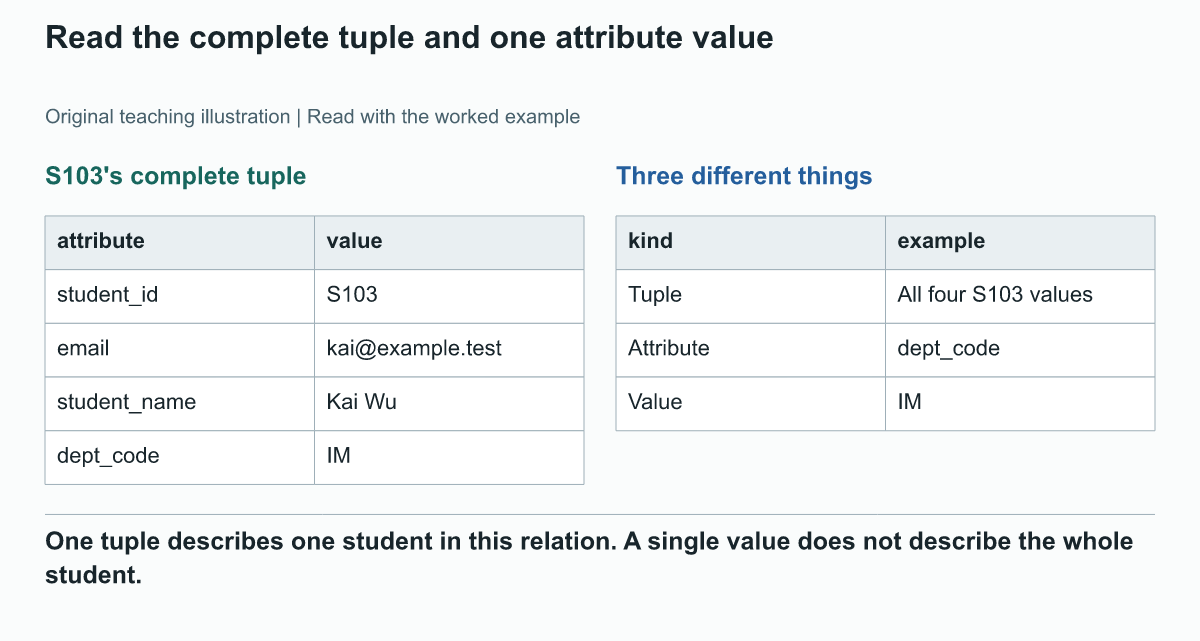

One tuple describes one student in this relation. A single value does not describe the whole student.


### Read the Diagram

There are four tuples and four attributes. S103's tuple contains its ID, email, name,
and department. `dept_code` is an attribute; `IM` is a value. A single value does not
describe the whole student. Repeating IM in two rows does not make those rows identical.


### Observe the Table

Run each example independently: it creates its own inputs in memory and closes its
connection. The Python example below creates and prints the supplied table. You are
not expected to recreate the code. Predict the tuple and attribute counts before running.


In [1]:
import sqlite3

db = sqlite3.connect(":memory:")
try:
    db.execute("CREATE TABLE student (student_id TEXT NOT NULL PRIMARY KEY, email TEXT, student_name TEXT, dept_code TEXT)")
    db.executemany("INSERT INTO student VALUES (?, ?, ?, ?)", [
        ("S101", "an@example.test", "An Chen", "IM"),
        ("S102", "bea@example.test", "Bea Lin", "FIN"),
        ("S103", "kai@example.test", "Kai Wu", "IM"),
        ("S104", "mira@example.test", "Mira Ho", "DES"),
    ])
    cursor = db.execute("SELECT * FROM student ORDER BY student_id")
    rows = cursor.fetchall()
    print(" | ".join(column[0] for column in cursor.description))
    for row in rows:
        print(" | ".join(row))
    print(f"Tuples: {len(rows)}; attributes: {len(cursor.description)}")
finally:
    db.close()


student_id | email | student_name | dept_code
S101 | an@example.test | An Chen | IM
S102 | bea@example.test | Bea Lin | FIN
S103 | kai@example.test | Kai Wu | IM
S104 | mira@example.test | Mira Ho | DES
Tuples: 4; attributes: 4


The output preserves all four values for each student. Its 16 displayed attribute
values are not 16 students. The supplied key declaration protects identifiers;
its syntax and formal key classification are not required in this first meeting.

**Practice:** Write S102's complete tuple and S104's department value. Check your tuple
against all four attribute names. Explain why these two requested answers have
different sizes.


## 2. A Domain Is More Than This Sample

A **domain** specifies possible atomic values, not just the values already present.
For a simplified course rule, suppose credits must be a whole number from 1 to 6.
The table currently contains 2 and 3, but 5 is also permitted by that rule.
The value 2.5 is not permitted even though it lies between the numeric endpoints.

**Predict:** Which of 5, 2.5, and 7 satisfies the stated domain? Which of those values
has already appeared in the sample? These are different questions.


### Allowed credits: whole numbers 1 through 6

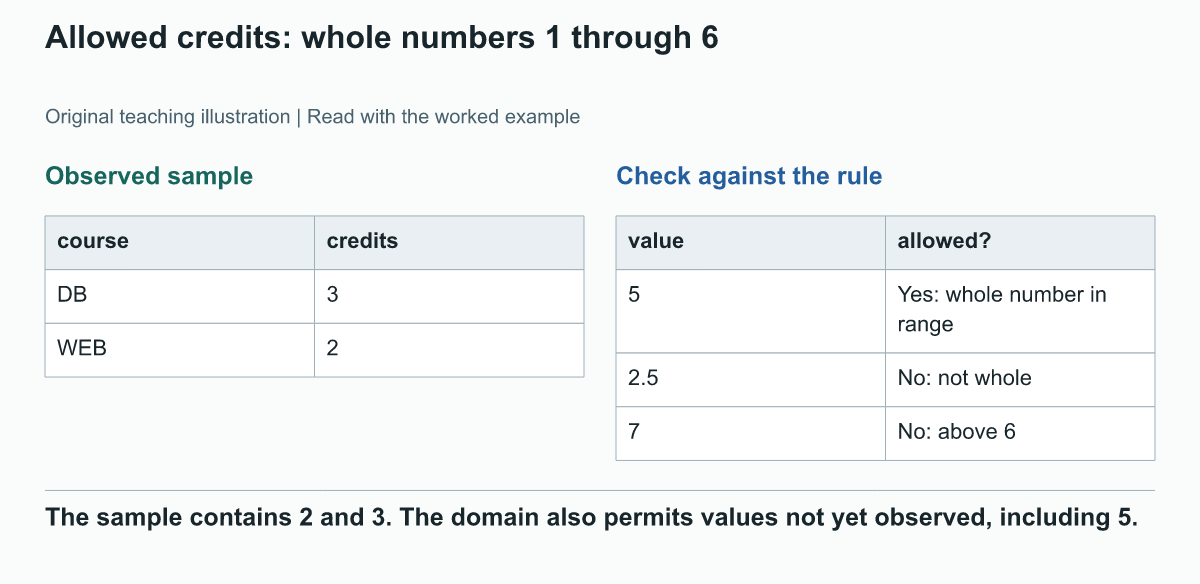

The sample contains 2 and 3. The domain also permits values not yet observed, including 5.


### Read the Diagram

Only 5 satisfies the whole-number rule. The sample is not an exhaustive list of
possible values: absence alone does not imply a domain violation. A database must
actually enforce the intended rule; a label such as INTEGER does not by itself prove
whole-number enforcement in every DBMS.

**Practice:** Define a domain for a room's seating capacity, including the allowed
numeric kind and bounds. Supply one permitted value missing from a two-row sample
and one rejected value. Check each against your stated rule, not your sample alone.


## 3. One Phone Value at a Time

In the basic relational model, attribute values are **atomic** within that model.
A multivalued attribute is represented separately rather than as a set inside one
attribute value. Atomicity is about the chosen representation, not whether a text
string can physically be split into characters.

Suppose S101 has two phone numbers. If the task is to find students by an individual
phone number, representing one student/phone pair per row makes that question explicit.
The schema becomes `student_phone(student_id, phone_number)`, where each tuple now
describes one association, not all information about one student.

**Predict:** How many phone rows represent S101's two numbers and S102's one number?
Does repeating S101 in two phone rows necessarily duplicate a complete tuple?


### A row can describe a student-phone association

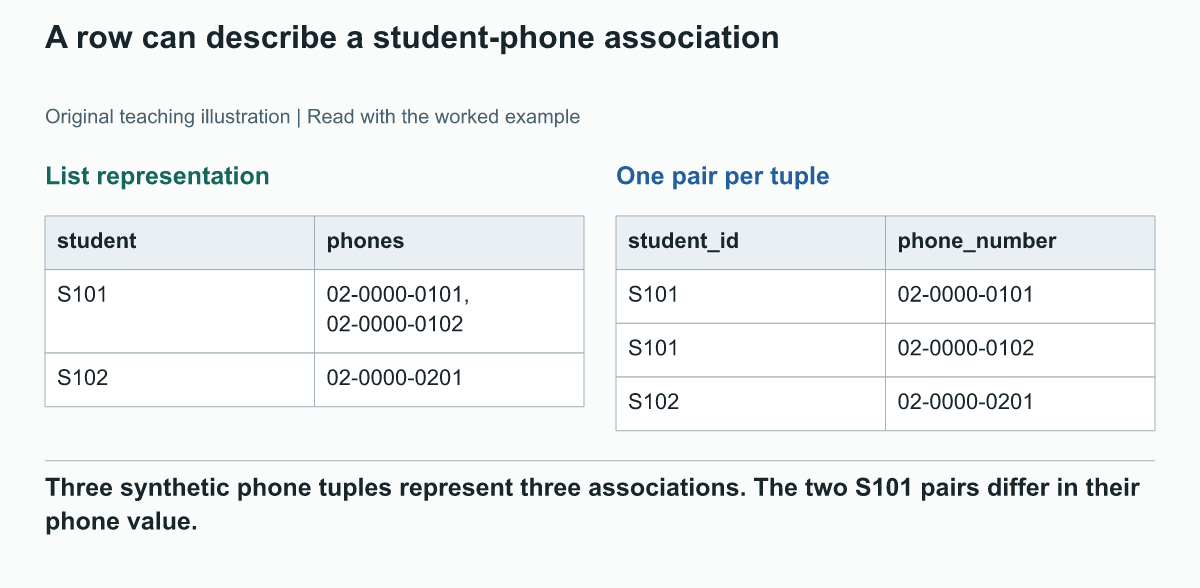

Three synthetic phone tuples represent three associations. The two S101 pairs differ in their phone value.


### Read the Diagram

There are three phone tuples. S101 repeats, but the two phone values differ, so the
complete pairs are distinct. This does not imply that one student must have one row
in every relation: row meaning depends on the relation's schema.

**Practice:** Add a second phone for S102 on paper. State the new tuple and row count.
Then identify the exact pair that would be a duplicate if inserted twice. Full ER
mapping and normalization rules are taught later; no 1NF test is required here.


## 4. Display Order and Repeated Values

A relation is a set, so its tuple order is not part of its logical meaning. A table
display still has an order. Sorting a display can change which row appears first
without changing the represented facts. Keep attribute names attached to their values:
exchanging a name and an email would change the tuple, not merely its display order.

**Predict:** If S101, S102, and S103 are displayed in reverse ID order, is a student
added or removed? If only their department values are displayed, how many copies
of IM appear before duplicates are removed?


### Same student facts, different display orders

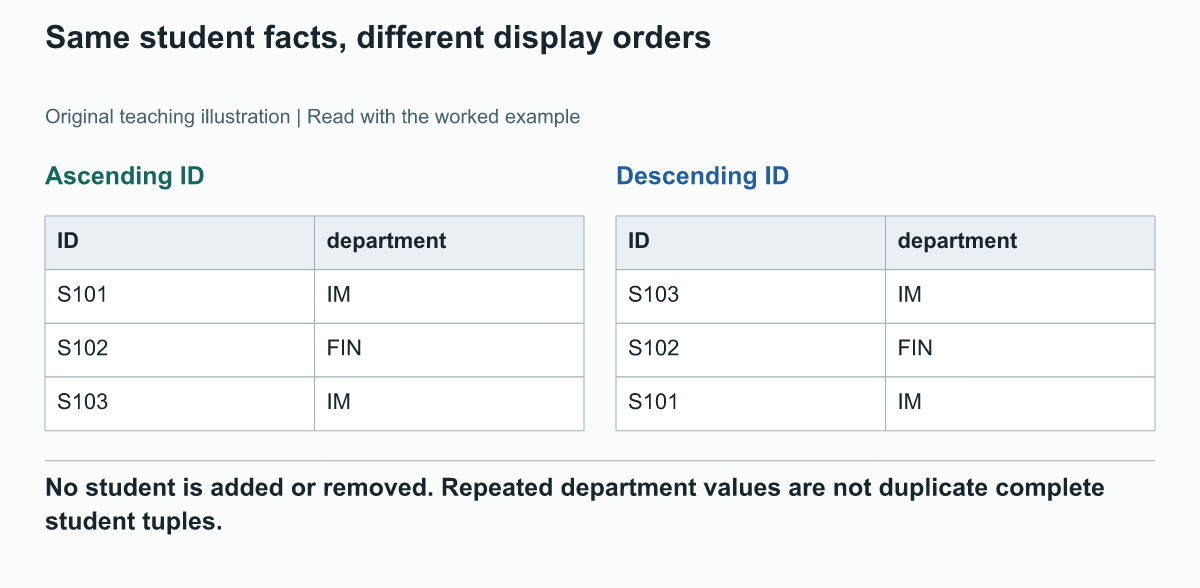

No student is added or removed. Repeated department values are not duplicate complete student tuples.


### Read the Diagram

The reversed display contains the same three student/department pairs. The department
list contains IM, FIN, IM. A set of departments contains only IM and FIN.
SQL normally retains duplicate result rows unless the query requests otherwise.


### Observe Repetition and Deduplication

Predict all four outputs, including the final stored row count. Each query below
reads the same three stored rows.


In [2]:
import sqlite3

db = sqlite3.connect(":memory:")
try:
    db.execute("CREATE TABLE student (student_id TEXT NOT NULL PRIMARY KEY, dept_code TEXT)")
    db.executemany("INSERT INTO student VALUES (?, ?)", [("S101", "IM"), ("S102", "FIN"), ("S103", "IM")])
    print("Reversed IDs:", db.execute("SELECT student_id FROM student ORDER BY student_id DESC").fetchall())
    print("Department result:", db.execute("SELECT dept_code FROM student ORDER BY student_id").fetchall())
    print("Distinct departments:", db.execute("SELECT DISTINCT dept_code FROM student ORDER BY dept_code").fetchall())
    print("Stored students:", db.execute("SELECT COUNT(*) FROM student").fetchone()[0])
finally:
    db.close()


Reversed IDs: [('S103',), ('S102',), ('S101',)]
Department result: [('IM',), ('FIN',), ('IM',)]
Distinct departments: [('FIN',), ('IM',)]
Stored students: 3


DISTINCT returns two department rows, but the stored table still has three students.
It did not delete one of the students in IM. SQL syntax is supplied here to let you
check the distinction; writing these queries is a later learning objective.

**Practice:** Add S104 in DES on paper. Predict the stored student count and the
distinct department count. Check separately whether you added a student and whether
you introduced a department value not previously present.


## 5. Why Identifiers Matter

A person's name may be shared by different people. Suppose the office has verified
that S103 and S105 are different students, both called Kai Wu. Their names alone
cannot choose the correct row. The case assigns each student a stable, distinct ID.
That is a business rule, not something established just by seeing unique values in
a small sample.

**Predict:** If an instruction says only "change Kai Wu's department," how many rows
could it refer to? Which additional value identifies S105 under the stated rule?


### One name can match two different students

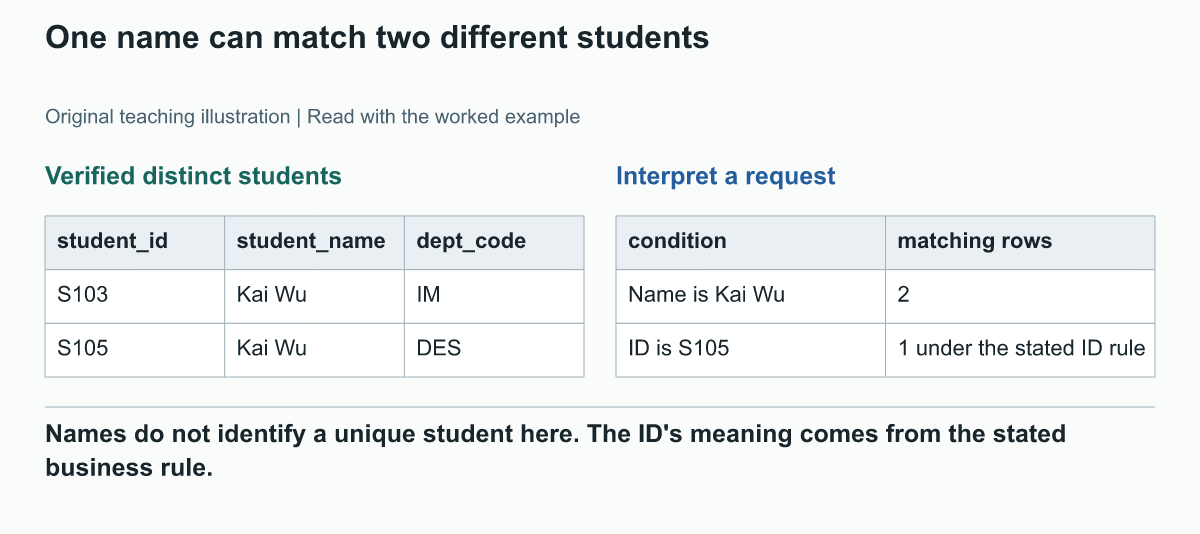

Names do not identify a unique student here. The ID's meaning comes from the stated business rule.


### Read the Diagram

The name matches two students. S105 identifies the second one under the rule.
Adding a random attribute does not automatically create a reliable identifier;
the rule must establish how it distinguishes permitted records.

**Practice:** Explain why a newly observed student with an unused name would not
prove that names are always unique. Use the two Kai Wu rows as a counterexample.
Candidate, primary, composite, and foreign key definitions are for the continuation.


## First-Meeting Summary and Practice

One tuple expresses one fact appropriate to its relation. Attributes give values
their roles; domains constrain possible values. Repeated values differ from repeated
complete tuples. Display order differs from stored facts. Identifiers require rules.

| Question | Your response | Evidence to check |
|---|---|---|
| What is S103's complete tuple in the first table? | | All four named attributes |
| Can an allowed domain value be absent from the sample? | | Rule and a concrete value |
| Did DISTINCT remove a stored student? | | Final stored row count |
| Why is a name insufficient in the last example? | | Two distinct IDs with the same name |

Keep one prediction, the observed result, and either your correction or an explanation
of why your prediction was correct. Questions support classroom discussion and review;
only instructor-assigned submissions are graded.

**Stop here for the first meeting.** The continuation of this chapter will cover
formal keys, entity integrity, referential integrity, and constraint violations.
Chapter 8 then expresses queries as relational-algebra operations. Neither continuation
is an extra task to finish before the next class unless explicitly assigned.


## Continue: Keys and Integrity Constraints

Resume here after the first-meeting stopping point. This continuation covers core
Sections 5.2-5.3 and the needed notation from 5.1. SQL is supplied to check predictions;
independent SQL writing begins in Chapter 6. Explain the rules before running code.


## 6. Read a Schema and a Missing Value

For a relation schema R(A1, ..., An), R is its name, A1 through An are attributes,
and n is its **degree**, the number of attributes. A state r(R) is its current set
of tuples. For a tuple t, t[A] means its value for attribute A.

Let student(student_id, student_name, dept_code) contain
t = (S103, Kai Wu, IM). The degree is 3 and t[dept_code] is IM. Adding a student
changes the state and tuple count, not the degree.

**NULL** marks a missing, unknown, or inapplicable value. It is not zero or an empty
string. Here a NULL department means assignment has not been recorded.

**Predict:** If S104 has a NULL department, how many attributes does its tuple have?
Can its department be inferred from S103?


### One missing value does not remove an attribute

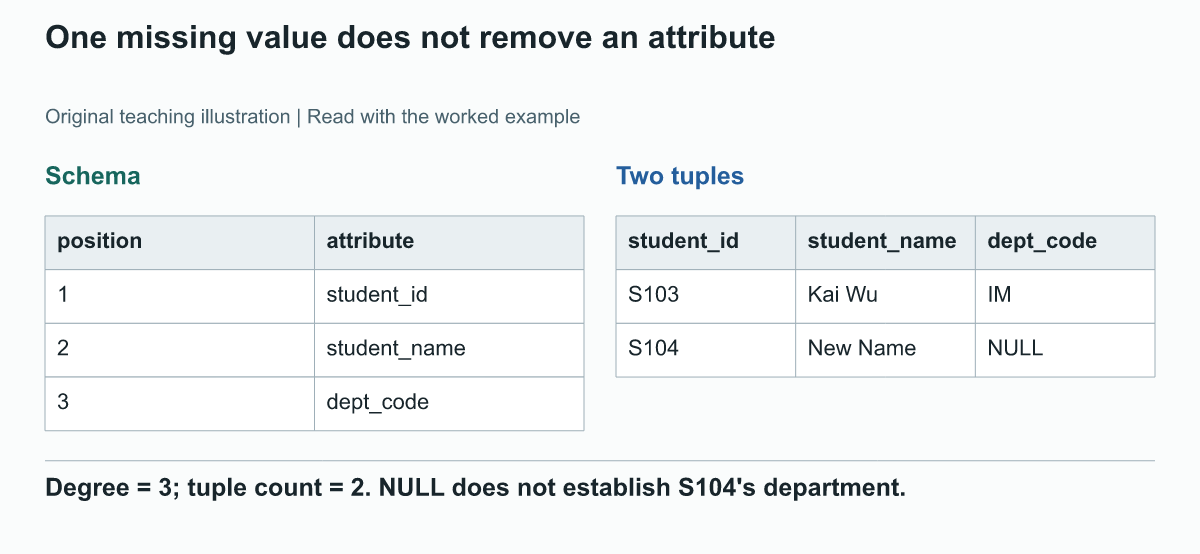

Degree = 3; tuple count = 2. NULL does not establish S104's department.


### Read the Diagram

The tuple still has three positions. NULL is not an extra department. No stored
evidence assigns S104 to IM or proves that two missing departments are equal.

**Practice:** Write a three-attribute course schema and one tuple. Identify its degree
and a value using t[A]. Replace an optional value with NULL and state what is unknown.
Check that you did not remove the attribute.


## 7. Superkeys, Candidate Keys, and the Primary Key

A **superkey** is a set of attributes whose combined values must distinguish tuples
in every valid state. A **candidate key** is a minimal superkey: removing any
attribute destroys that guarantee. Minimal does not mean that all candidate keys
must have the same number of attributes.

Assume every student has one unique, non-missing student_id and one unique,
non-missing institution-issued email. Names may repeat. These are this example's
rules, not claims about every university.

| student_id | email | student_name |
|---|---|---|
| S101 | an@example.test | An Chen |
| S102 | bea@example.test | Bea Lin |
| S103 | kai@example.test | Kai Wu |

Under these rules, {student_id} and {email} are candidate keys.
{student_id, student_name} is a superkey but not a candidate key: removing the name
preserves uniqueness. Distinct names in this sample do not establish a key rule.

Choose one candidate key as the **primary key**. We choose student_id. Email remains
another candidate key and must still be unique and non-missing under our rule.

**Predict:** Is {student_id, email} minimal? Does choosing student_id as the primary
key now allow two students to share an email?


### Uniqueness and minimality are different checks

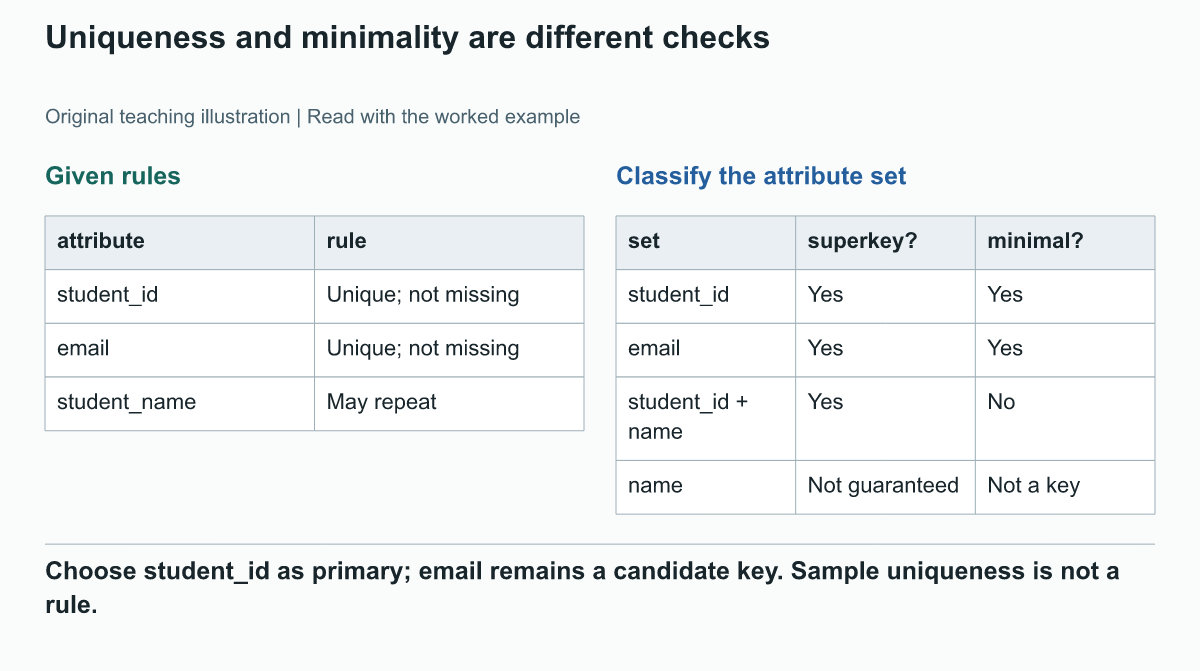

Choose student_id as primary; email remains a candidate key. Sample uniqueness is not a rule.


### Read the Diagram

Either attribute identifies a student on its own, so their pair is not minimal.
Choosing a primary key does not cancel the email rule. A repeated name is permitted;
a repeated email is not permitted in this example.

**Practice and comparison:** Compare {student_name}, {student_id, student_name}, and
{email}. Explain uniqueness under the rules and whether any attribute can be removed.
Groups should cite a rule or a permitted counterexample, not just distinct sample
values. Compare responses, then retain your own corrected explanation.


## 8. A Composite Key Identifies a Combination

A **composite key** has multiple attributes. A student may take a course in different
terms but may enroll only once in the same course and term. An enrollment tuple
describes one student-course-term registration.

| student_id | course_id | term |
|---|---|---|
| S101 | DB1 | F26 |
| S101 | DB1 | S27 |
| S102 | DB1 | F26 |

The candidate key is {student_id, course_id, term}. A student can take several courses,
a course can have several students, and a student-course pair can recur in another
term. All three attributes are necessary under these rules.

**Predict:** Which new triple repeats a key: (S101, DB1, F26) or (S102, DB1, S27)?
Would {student_id, course_id} permit the retake already displayed?


### A permitted retake needs the term in the key

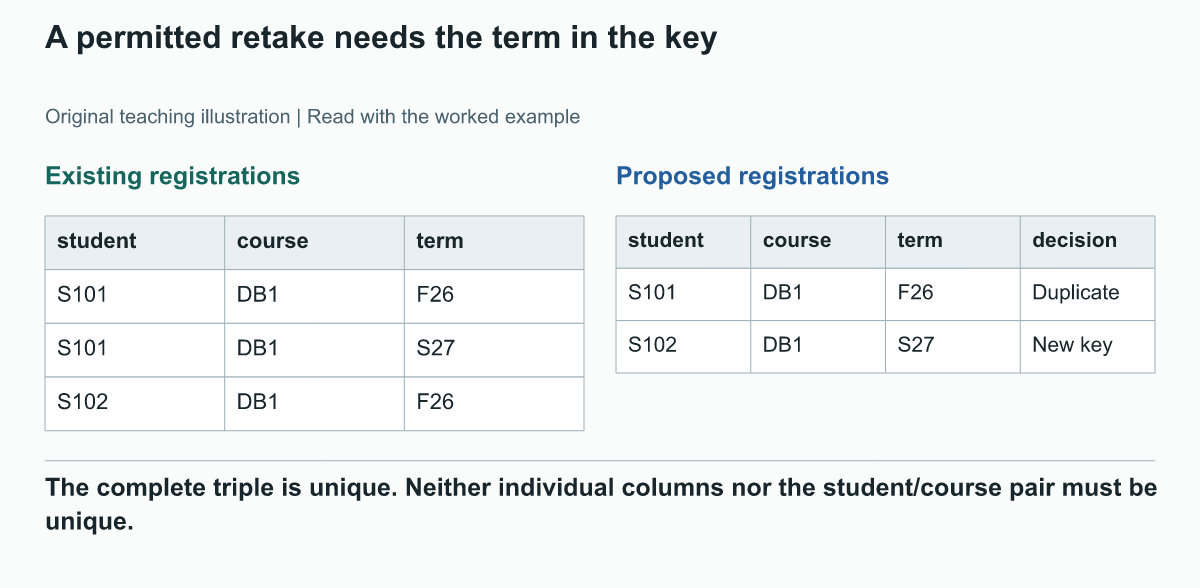

The complete triple is unique. Neither individual columns nor the student/course pair must be unique.


### Read the Diagram

The first triple duplicates an existing key; the second is a new combination.
The two-attribute proposal would reject S101's permitted retake. A composite
primary key is one key, not three independent uniqueness constraints.

**Practice:** Add S101 in AI1 during F26. Explain why repeating S101 and F26 is allowed.
Remove each key attribute in turn and give two possible registrations it would fail
to distinguish. Check each proposal against the rules, not only the sample.


## 9. Connect Relations with Foreign Keys

A **relational database schema** contains several relation schemas and their
constraints. A valid database state satisfies the constraints across all its relations.

**Entity integrity** requires every primary-key component to be non-NULL.
**Referential integrity** requires a reference to identify an existing referenced
tuple, unless a missing reference is permitted. Our single-column department
reference is optional; the registration references are mandatory.

A **foreign key** is the referencing attribute or attribute set. Here student.dept_code
references department.dept_code. Foreign keys may repeat: many students can belong
to IM. Attribute names need not match; their compatible meanings, domains, and
declared reference matter.

| Relation | Primary key | Foreign keys |
|---|---|---|
| department | dept_code | None |
| student | student_id | dept_code references department |
| course | course_id | None |
| enrollment | student_id, course_id, term | student_id references student; course_id references course |

Arrows point from a foreign key to its referenced key. This is a relational-schema
diagram, not ER/EER notation or program execution.

**Predict:** May two students reference IM? May S104 reference absent department MED?
Must a student exist before that student's registration is inserted?


### Foreign keys point to referenced keys

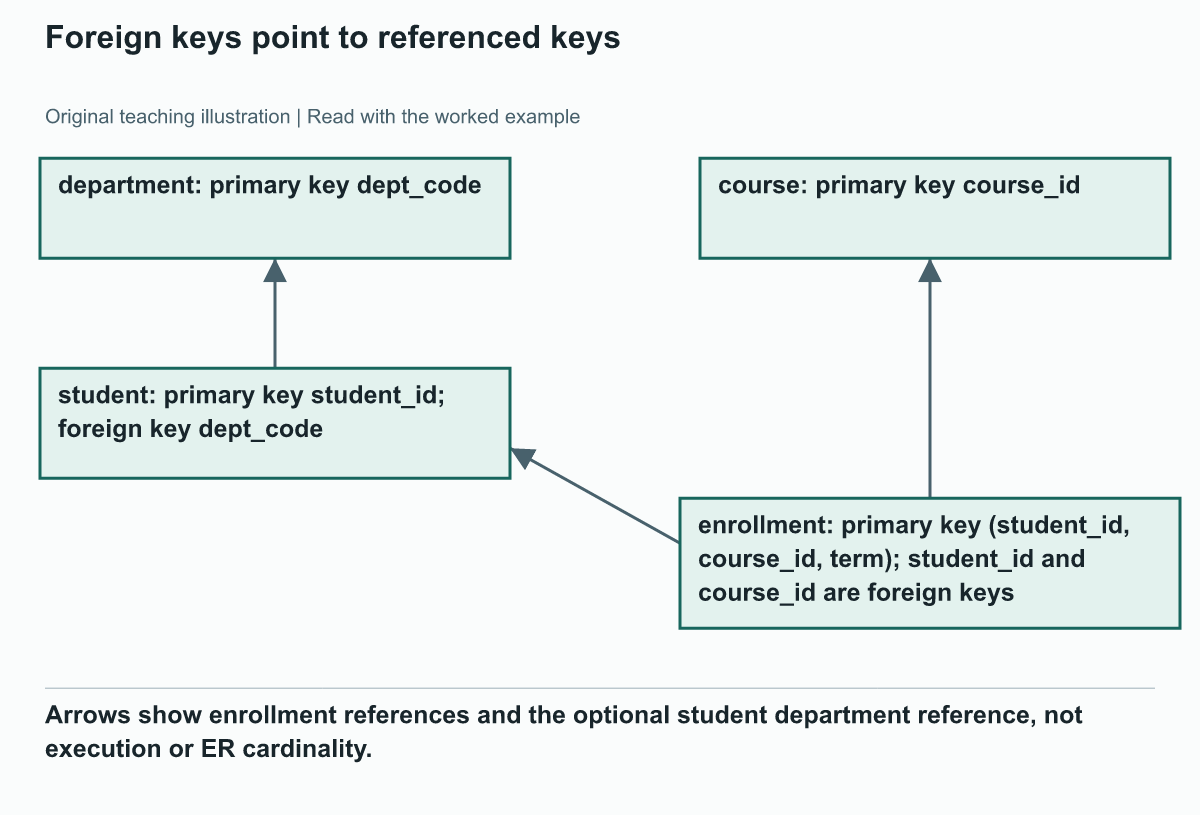

Arrows show enrollment references and the optional student department reference, not execution or ER cardinality.


### Read the Diagram

Repeated IM references are allowed; absent MED is not. Enrollment must reference
an existing student and course. A composite foreign key must match the complete
referenced combination; independent matches for its components are insufficient.

A reference can point into the same relation. Under a separate optional mentor
rule, student.mentor_id could reference student.student_id. S103 with mentor_id S101
would reference S101's tuple; NULL would record no mentor.

**Practice:** Draw enrollment's two arrows. Propose a row whose ID is new but whose
department is invalid. Check uniqueness and reference existence separately. For the
mentor example, identify the referenced tuple rather than creating a new person.


## 10. Build and Inspect a Small Database

Run this setup cell before the following examples. It defines a function that creates
a fresh in-memory database each time. Closing the connection removes that example's
temporary contents; nothing is saved to your computer.

The SQL creates referenced tables first and inserts parents before children.
PRIMARY KEY enforces uniqueness; explicit NOT NULL protects every key component.
UNIQUE plus NOT NULL implements the email rule. The credits domain requires whole
numbers from 1 through 6: CHECK tests the stored type and range, and NOT NULL
rejects missing credits. The optional department omits NOT NULL.

**Predict:** What should PRAGMA foreign_keys return? How many enrollment rows should
exist? Which attributes form its primary key?


In [3]:
import sqlite3

def new_database():
    db = sqlite3.connect(":memory:", isolation_level=None)
    db.execute("PRAGMA foreign_keys = ON")
    assert db.execute("PRAGMA foreign_keys").fetchone()[0] == 1
    db.executescript("""
        CREATE TABLE department (dept_code TEXT NOT NULL PRIMARY KEY);
        CREATE TABLE student (
            student_id TEXT NOT NULL PRIMARY KEY,
            email TEXT NOT NULL UNIQUE,
            student_name TEXT NOT NULL,
            dept_code TEXT REFERENCES department(dept_code)
                ON DELETE RESTRICT ON UPDATE RESTRICT
        );
        CREATE TABLE course (
            course_id TEXT NOT NULL PRIMARY KEY,
            credits INTEGER NOT NULL
                CHECK(typeof(credits) = 'integer' AND credits BETWEEN 1 AND 6)
        );
        CREATE TABLE enrollment (
            student_id TEXT NOT NULL REFERENCES student(student_id)
                ON DELETE RESTRICT ON UPDATE RESTRICT,
            course_id TEXT NOT NULL REFERENCES course(course_id)
                ON DELETE RESTRICT ON UPDATE RESTRICT,
            term TEXT NOT NULL,
            PRIMARY KEY (student_id, course_id, term)
        );
        INSERT INTO department VALUES ('IM'), ('FIN'), ('DES');
        INSERT INTO student VALUES
            ('S101','an@example.test','An Chen','IM'),
            ('S102','bea@example.test','Bea Lin','FIN'),
            ('S103','kai@example.test','Kai Wu','IM');
        INSERT INTO course VALUES ('DB1',3), ('AI1',2);
        INSERT INTO enrollment VALUES
            ('S101','DB1','F26'), ('S101','DB1','S27'), ('S102','DB1','F26');
    """)
    return db

db = new_database()
try:
    print("Foreign keys:", db.execute("PRAGMA foreign_keys").fetchone()[0])
    print("Enrollment:", db.execute("SELECT * FROM enrollment ORDER BY student_id, term").fetchall())
    print("Key positions:", [(row[1], row[5]) for row in db.execute("PRAGMA table_info(enrollment)")])
finally:
    db.close()


Foreign keys: 1
Enrollment: [('S101', 'DB1', 'F26'), ('S101', 'DB1', 'S27'), ('S102', 'DB1', 'F26')]
Key positions: [('student_id', 1), ('course_id', 2), ('term', 3)]


Positions 1, 2, and 3 describe one composite key. Both S101 rows survive because
their terms differ. Foreign keys = 1 confirms this connection's setting, not
that every business rule is encoded.

SQLite details: enable foreign keys on each connection before a transaction.
Ordinary SQLite tables can allow NULL in some primary-key declarations without
explicit NOT NULL. UNIQUE alone permits multiple NULLs. The DDL avoids both
behaviors for required identifiers. INTEGER alone does not enforce our full
credits rule.

**Practice:** Locate the email and credits rules. Explain what would be lost by
removing UNIQUE or CHECK. Rerun setup and verify three registrations, not six.


### Create parents before inserting references

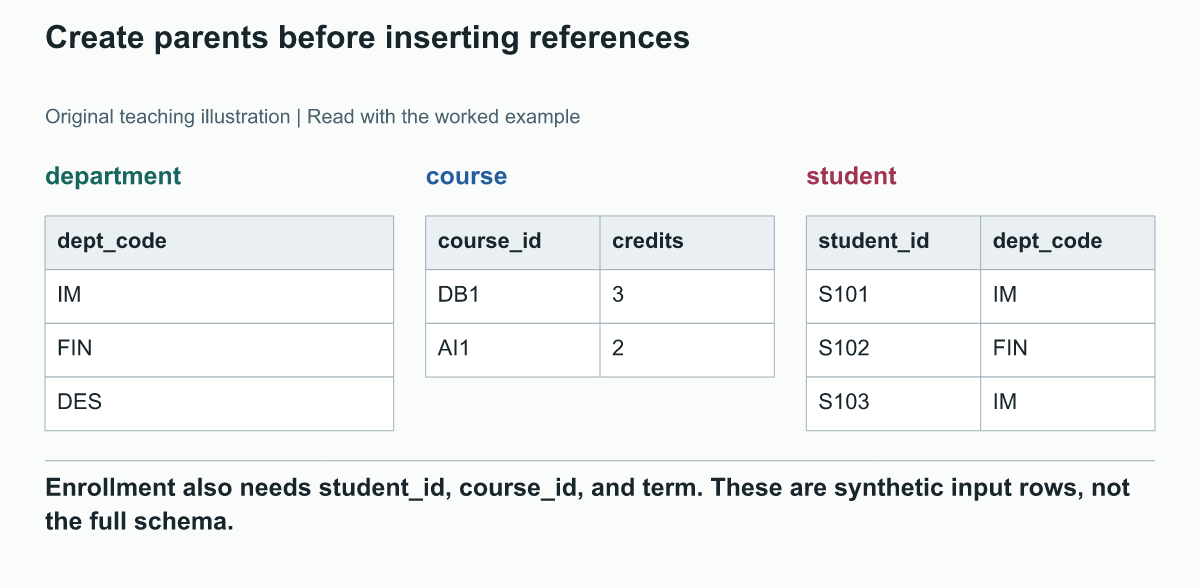

Enrollment also needs student_id, course_id, and term. These are synthetic input rows, not the full schema.


## 11. Predict Accepted and Rejected Changes

INSERT can violate domain, key, entity-integrity, or referential-integrity rules.
UPDATE must satisfy the rules for its new values and affected references.
Among these four constraint classes, DELETE can violate referential integrity
by removing a referenced tuple. Other business rules can impose further restrictions.

Each attempt starts from the same state. Success prints ACCEPTED; a constraint
failure prints BLOCKED. Starting fresh keeps one attempt from affecting another.

**Predict:** Classify every attempt and name the specific value and rule for each
rejection. Pay attention to NULL, fractional credits, repeated names, and MED.


### A new ID alone does not make a new row valid

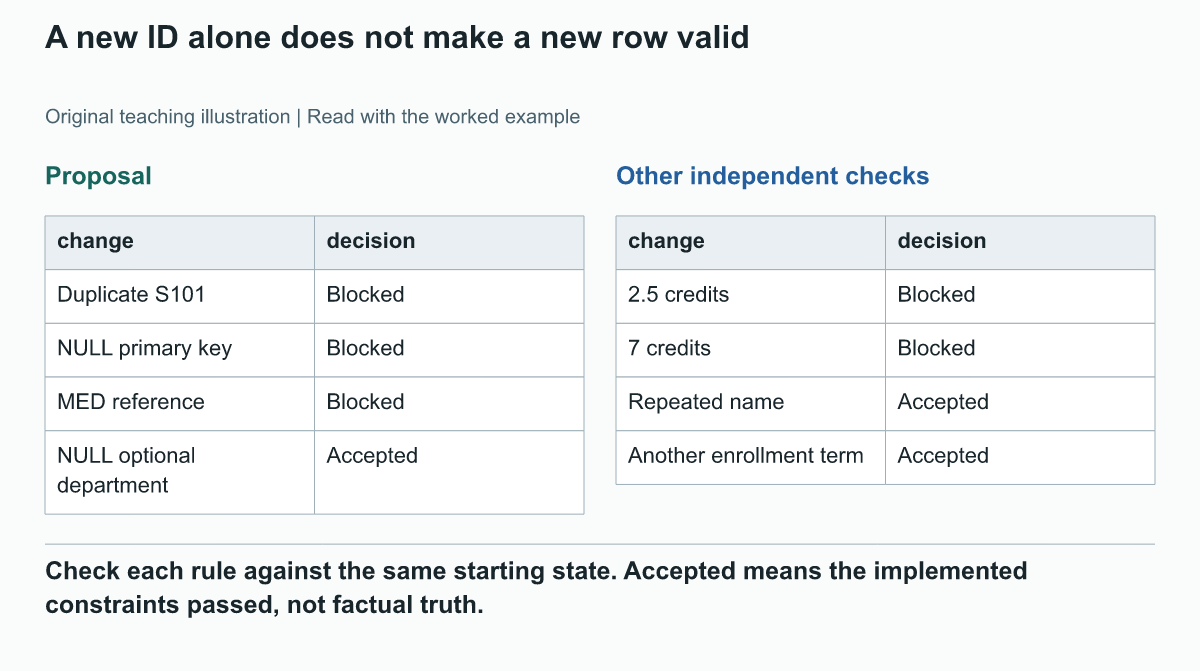

Check each rule against the same starting state. Accepted means the implemented constraints passed, not factual truth.


### Compare the Rules

A repeated primary key breaks uniqueness; a missing primary-key component breaks
entity integrity. A new ID can still violate another constraint. None of these
checks establishes the factual truth of a student's name.


In [4]:
cases = [
    ("Duplicate ID", "INSERT INTO student VALUES ('S101','new@example.test','New Name','IM')"),
    ("Missing ID", "INSERT INTO student VALUES (NULL,'new@example.test','New Name','IM')"),
    ("Duplicate email", "INSERT INTO student VALUES ('S104','an@example.test','New Name','IM')"),
    ("Missing email", "INSERT INTO student VALUES ('S104',NULL,'New Name','IM')"),
    ("Absent department", "INSERT INTO student VALUES ('S104','new@example.test','New Name','MED')"),
    ("Optional department", "INSERT INTO student VALUES ('S104','new@example.test','New Name',NULL)"),
    ("Repeated name", "INSERT INTO student VALUES ('S104','new@example.test','Kai Wu','DES')"),
    ("Fractional credits", "INSERT INTO course VALUES ('X1',2.5)"),
    ("Out-of-range credits", "INSERT INTO course VALUES ('X1',7)"),
    ("Missing credits", "INSERT INTO course VALUES ('X1',NULL)"),
    ("Duplicate registration", "INSERT INTO enrollment VALUES ('S101','DB1','F26')"),
    ("Missing key component", "INSERT INTO enrollment VALUES ('S101','DB1',NULL)"),
    ("Missing student reference", "INSERT INTO enrollment VALUES ('S999','DB1','F26')"),
    ("Another term", "INSERT INTO enrollment VALUES ('S102','DB1','S27')"),
    ("Update to absent department", "UPDATE student SET dept_code='MED' WHERE student_id='S101'"),
    ("Update to existing department", "UPDATE student SET dept_code='DES' WHERE student_id='S101'"),
    ("Update referenced ID", "UPDATE student SET student_id='S109' WHERE student_id='S101'"),
    ("Delete referenced student", "DELETE FROM student WHERE student_id='S101'"),
    ("Delete unreferenced student", "DELETE FROM student WHERE student_id='S103'"),
    ("Delete one registration", "DELETE FROM enrollment WHERE student_id='S101' AND term='F26'"),
]
for label, sql in cases:
    db = new_database()
    try:
        before = list(db.iterdump())
        try:
            db.execute(sql)
        except sqlite3.IntegrityError:
            assert list(db.iterdump()) == before
            print(label + ": BLOCKED")
        else:
            print(label + ": ACCEPTED")
        assert not db.execute("PRAGMA foreign_key_check").fetchall()
    finally:
        db.close()


Duplicate ID: BLOCKED
Missing ID: BLOCKED
Duplicate email: BLOCKED
Missing email: BLOCKED
Absent department: BLOCKED
Optional department: ACCEPTED
Repeated name: ACCEPTED
Fractional credits: BLOCKED
Out-of-range credits: BLOCKED
Missing credits: BLOCKED
Duplicate registration: BLOCKED
Missing key component: BLOCKED
Missing student reference: BLOCKED
Another term: ACCEPTED
Update to absent department: BLOCKED
Update to existing department: ACCEPTED
Update referenced ID: BLOCKED
Delete referenced student: BLOCKED
Delete unreferenced student: ACCEPTED
Delete one registration: ACCEPTED


S104's NULL department is allowed because that reference is optional. The NULL
registration term is blocked because every primary-key component is required.
S103 can be deleted because no initial enrollment references it; S101 cannot.
The rejected changes leave the initial state unchanged in these demonstrations.

**Practice:** Predict changing DB1's credits to 0 and inserting a registration for
course Z9. Repair each proposal using a permitted value, then verify it. Retain
the input, prediction, output, named rule, and correction or confirmation.


## 12. Choose What Happens to References

RESTRICT rejects a parent deletion while references exist. CASCADE deletes the
referencing rows. SET NULL preserves those rows but clears their foreign key.
SET DEFAULT assigns the declared default; a non-NULL default must still identify
an existing parent. SET NULL cannot satisfy a NOT NULL foreign-key declaration.

These policies have different consequences for retained data. They are not
interchangeable ways to silence an error. Here two contacts reference IM;
the contact department is optional, with default UNASSIGNED.

**Predict:** When IM is deleted, how many contacts remain under each action, and
what department values remain?


### Deleting IM has four different consequences

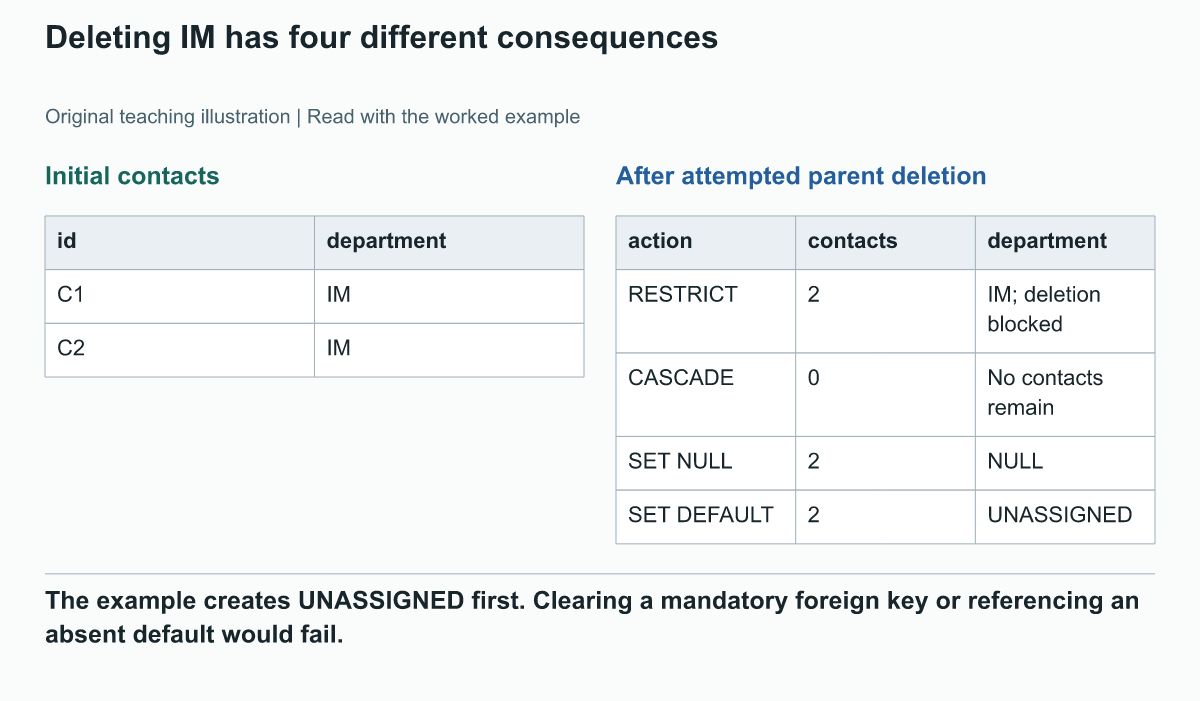

The example creates UNASSIGNED first. Clearing a mandatory foreign key or referencing an absent default would fail.


### Follow the References

Every action starts with identical rows. Only the deletion policy changes, so the
row counts and values can be compared under the same starting conditions.


In [5]:
for action in ("RESTRICT", "CASCADE", "SET NULL", "SET DEFAULT"):
    db = sqlite3.connect(":memory:", isolation_level=None)
    try:
        db.execute("PRAGMA foreign_keys = ON")
        db.executescript(f"""
            CREATE TABLE parent (code TEXT NOT NULL PRIMARY KEY);
            CREATE TABLE contact (
                id TEXT NOT NULL PRIMARY KEY,
                code TEXT DEFAULT 'UNASSIGNED' REFERENCES parent(code) ON DELETE {action}
            );
            INSERT INTO parent VALUES ('IM'), ('UNASSIGNED');
            INSERT INTO contact VALUES ('C1','IM'), ('C2','IM');
        """)
        try:
            db.execute("DELETE FROM parent WHERE code='IM'")
            result = "ACCEPTED"
        except sqlite3.IntegrityError:
            result = "BLOCKED"
        rows = db.execute("SELECT id, code FROM contact ORDER BY id").fetchall()
        values = [(i, "NULL" if c is None else c) for i, c in rows]
        print(action, result, values)
        assert not db.execute("PRAGMA foreign_key_check").fetchall()
    finally:
        db.close()


RESTRICT BLOCKED [('C1', 'IM'), ('C2', 'IM')]
CASCADE ACCEPTED []
SET NULL ACCEPTED [('C1', 'NULL'), ('C2', 'NULL')]
SET DEFAULT ACCEPTED [('C1', 'UNASSIGNED'), ('C2', 'UNASSIGNED')]


CASCADE removed both contacts; it did not just clear a value. SET NULL and SET
DEFAULT preserved both IDs. RESTRICT kept both parent and contacts by rejecting
the deletion.

**Practice:** A rule requires retaining contacts after a department closes. Which
action conflicts with that rule? Compare the others using whether an unassigned
department is permitted. Judge the retained data, not merely command success.


## 13. Business Rules and a Unit of Work

Existing student and course IDs do not enforce "at most two courses per student
per term." If S101 already has DB1 and AI1, adding existing course X1 can satisfy
both references while violating that separate rule. Our schema does not enforce
that limit; a further mechanism would be needed.

A rule about a change may also depend on the previous value. "Approved credits
may only increase" rejects 3 becoming 2, although both satisfy the domain.
This **transition constraint** differs from a rule about the new state alone.

**Predict:** Does an empty foreign_key_check result prove either business rule?


### Valid references do not enforce every intended rule

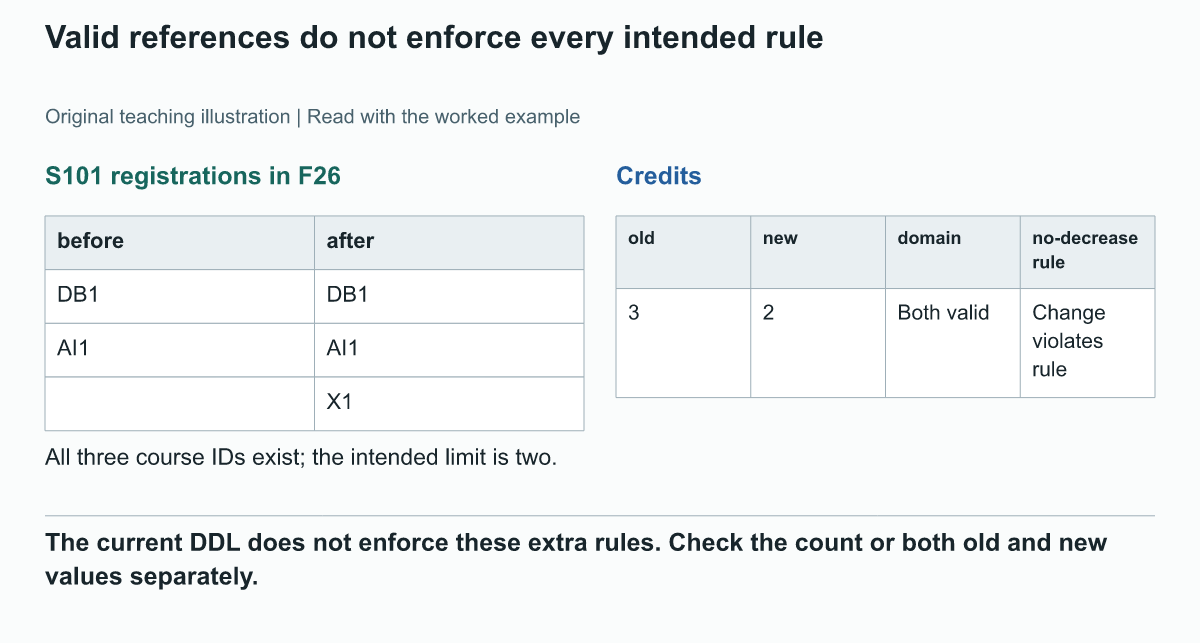

The current DDL does not enforce these extra rules. Check the count or both old and new values separately.


### Read the Diagram

Three existing course references can exceed the limit. Two permitted credit
values can violate a no-decrease rule. Passing implemented checks does not prove
that every intended rule was implemented.

**Practice:** Draw before/after rows for the third registration. Identify the count
a further check would need. For the credits rule, record both old and new values.
No additional trigger implementation is required here.

A **transaction** groups operations into one unit of work. Here creating S104 is
followed by a failed attempt to enroll S104 in absent course Z9. The code explicitly
rolls back both changes.

**Predict:** Should S104 remain after ROLLBACK? Is rejecting the second statement
alone the same as undoing the first insertion?


In [6]:
db = new_database()
try:
    db.execute("BEGIN")
    try:
        db.execute("INSERT INTO student VALUES ('S104','new@example.test','New Name','IM')")
        db.execute("INSERT INTO enrollment VALUES ('S104','Z9','F26')")
        db.execute("COMMIT")
    except sqlite3.IntegrityError:
        db.execute("ROLLBACK")
        print("Registration failed; both changes rolled back.")
    print("S104 rows:", db.execute("SELECT COUNT(*) FROM student WHERE student_id='S104'").fetchone()[0])
finally:
    db.close()


Registration failed; both changes rolled back.
S104 rows: 0


The explicit ROLLBACK undid S104's insertion. A statement failure does not generally
roll back an entire transaction automatically. Detailed ACID and transaction
theory remain in Chapter 20; this is the introductory concept from Section 5.3.4.

**Practice:** Describe the intended final state if both operations succeed. Explain
why inserting the student before its enrollment respects referential integrity.
Check the two operations as one intended action.


## Chapter Summary

Candidate keys are minimal superkeys; one is designated primary. Composite keys
identify complete combinations. Entity integrity requires every primary-key
component. Referential integrity checks references between relations. Domains and
further business rules answer different questions.

For one proposed change, keep its starting rows, your prediction, the observed
result, the exact rule, and a correction or confirmation. For a paper example,
keep your worked result without claiming database execution. Only assigned work
is submitted.

Continue with Chapter 8: The Relational Algebra and Relational Calculus, selected
algebra operations. Chapter 6 then teaches SQL writing; ER/EER design and mapping
follow later in Chapters 3-4 and 9.

Implementation references: [SQLite CREATE TABLE](https://www.sqlite.org/lang_createtable.html)
and [SQLite foreign keys](https://www.sqlite.org/foreignkeys.html).
